In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

#中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

df = pd.read_csv(r'D:\Python-Learn\steam-gamedataset\data storage\01-platform-evolution\02_genre_evolution.csv')


In [28]:
print(f"行数: {len(df)}, 列数: {len(df.columns)}")
print(f"列名: {list(df.columns)}")
print(f"年份范围: {df['release_year'].min():.0f} – {df['release_year'].max():.0f}")
print(f"\n前 5 行:")
display(df.head())
print(f"\n缺失值统计:")
display(df.isnull().sum())

行数: 326, 列数: 5
列名: ['genre_name', 'release_year', 'game_count', 'avg_price', 'free_count']
年份范围: 2006 – 2026

前 5 行:


,genre_name,release_year,game_count,avg_price,free_count
0,Strategy,2006.0,25,8.66,0
1,Casual,2006.0,19,5.20,1
2,Action,2006.0,18,11.69,0
3,Indie,2006.0,10,10.30,1
4,Action,2007.0,47,8.28,1



缺失值统计:


genre_name       0
release_year     0
game_count       0
avg_price       11
free_count       0
dtype: int64

In [29]:
#2026年数据缺失过多
df_full = df[df['release_year'] <= 2025].copy()
print(f"\n过滤 2026 后: {len(df_full)} 行")
display(df_full.isnull().sum())


过滤 2026 后: 317 行


genre_name      0
release_year    0
game_count      0
avg_price       4
free_count      0
dtype: int64

In [30]:
# 热力图 类型 × 年份  游戏数量
heatmap_data = df_full.pivot_table(
    index='genre_name',
    columns='release_year',
    values='game_count',
    aggfunc='sum'
).fillna(0)

print(len(heatmap_data))
#总共有26种游戏类型

26


Text(222.72222222222223, 0.5, '游戏类型')

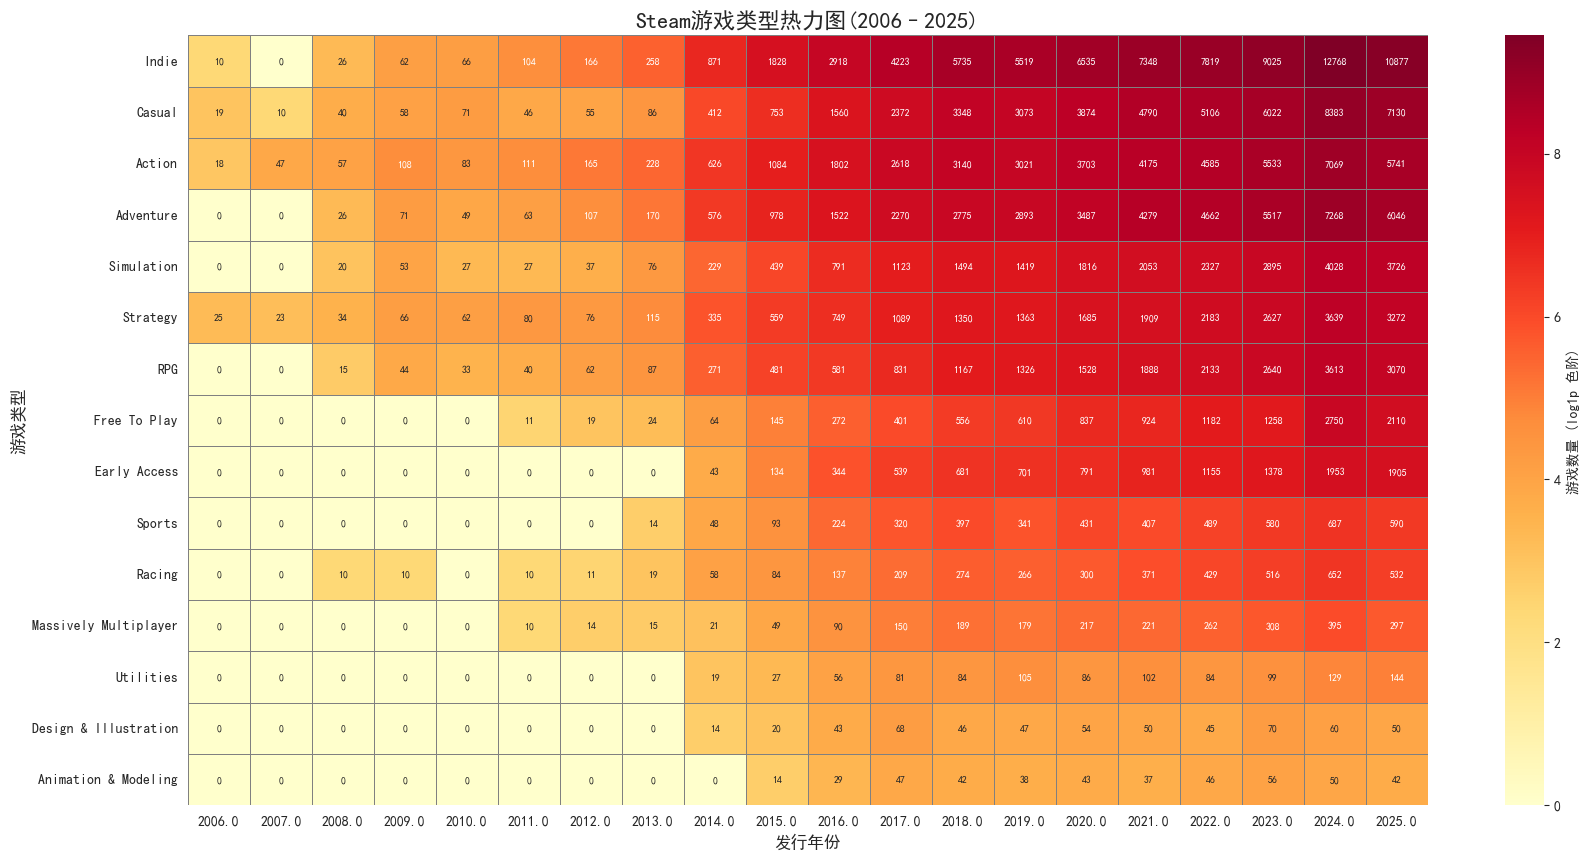

In [36]:
# 按总游戏数排序，取前 15 个主要类型
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']

heatmap_data['总计'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('总计', ascending=False)
top_genres = heatmap_data.head(15).index.tolist()
heatmap_data = heatmap_data.drop(columns=['总计'])
heatmap_plot = heatmap_data.loc[top_genres]

# 对数变换以改善颜色分布
heatmap_log = np.log1p(heatmap_plot)
# 绘制热力图
fig,ax = plt.subplots(figsize=(20, 10))
sns.heatmap(
    heatmap_log,
    cmap='YlOrRd',
    annot=heatmap_plot.astype(int),  # 显示原始值
    fmt='d',
    linewidths=0.5,
    linecolor='gray',
    ax=ax,
    cbar_kws={'label': '游戏数量 (log1p 色阶)'},
    annot_kws={'fontsize': 7}
)
ax.set_title('Steam游戏类型热力图(2006–2025)', fontsize=16, fontweight='bold')
ax.set_xlabel('发行年份', fontsize=12)
ax.set_ylabel('游戏类型', fontsize=12)


In [82]:
# 交互式热力图

fig = px.imshow(
    heatmap_log,
    labels=dict(x="发行年份", y="游戏类型", color="游戏数(log1p)"),
    title="Steam 游戏类型热力图 (交互式)",
    aspect="auto",
    color_continuous_scale="YlOrRd",
    text_auto='.0f'  # 显示 log 值，四舍五入
)
fig.update_xaxes(side="bottom", dtick=1)
fig.update_layout(height=700, width=1100)
fig.show()

fig.write_html(r'D:\Python-Learn\steam-gamedataset\png\steam_heatmap_interactive.html')

In [60]:
# 气泡图-动态

# 取每年Top12类型（按游戏数量）

df_anim = df_full.copy()
yearly_top = []
for year in sorted(df_anim['release_year'].unique()):
    year_data = df_anim[df_anim['release_year'] == year].nlargest(12, 'game_count')
    yearly_top.append(year_data)
df_top = pd.concat(yearly_top)

# 填充 Free To Play 等无价格数据的类型
df_top['avg_price_filled'] = df_top['avg_price'].fillna(0)
df_top['size_scaled'] = np.sqrt(df_top['game_count']) * 2  # 气泡大小缩放

# 标记重点类型
df_top['highlight'] = df_top['genre_name'].apply(
    lambda x: '★ 重点类型' if x in ['Strategy', 'Indie', 'Action'] else '其他类型'
)

df_top['genre_name'].unique()
df_top.head(5)

,release_year,genre_name,game_count,avg_price,free_count,avg_price_filled,size_scaled,highlight
0,2006,Strategy,25.0,8.66,0.0,8.66,10.000000,★ 重点类型
1,2006,Casual,19.0,5.20,1.0,5.20,8.717798,其他类型
2,2006,Action,18.0,11.69,0.0,11.69,8.485281,★ 重点类型
3,2006,Indie,10.0,10.30,1.0,10.30,6.324555,★ 重点类型
4,2006,Adventure,0.0,NaN,NaN,0.00,0.000000,其他类型


In [83]:
fig = px.scatter(
    df_top,
    x='release_year',
    y='game_count',
    size='game_count',
    color='genre_name',
    animation_frame='release_year',
    hover_name='genre_name',
    hover_data={
        'game_count': True,
        'avg_price_filled': ':.2f',
        'release_year': False
    },
    size_max=80,
    range_x=[2005, 2026],
    range_y=[-500, 14000],
    title='Steam 游戏类型占比动画 (2006–2025)',
    category_orders={'genre_name': all_genres.tolist()},  # 固定12个类型的顺序
    labels={
        'release_year': '发行年份',
        'game_count': '游戏数量',
        'avg_price_filled': '均价(USD)'
    }
)
fig.update_layout(
    height=700,
    width=1100,
    xaxis=dict(dtick=1),
    legend=dict(itemclick='toggleothers', itemdoubleclick='toggle')
)
fig.show()

fig.write_html(r'D:\Python-Learn\steam-gamedataset\png\bubble_animation.html')

In [68]:
# 分析独立游戏（Index）

# 提取 Indie 数据
indie = df_full[df_full['genre_name'] == 'Indie'].sort_values('release_year').copy()
indie['yoy_growth'] = indie['game_count'].pct_change() * 100  # 同比增长率

# 计算每年总游戏数和 Indie 份额
yearly_total = df_full.groupby('release_year')['game_count'].sum().reset_index() # 把所有类型的game_count加起来，得到每年整个Steam平台的总游戏数
yearly_total.columns = ['release_year', 'total_games']
indie = indie.merge(yearly_total, on='release_year')  # 将Indie数据与年度总游戏数按年份合并
indie['market_share'] = (indie['game_count'] / indie['total_games']) * 100

indie.head(5)

,release_year,genre_name,game_count,avg_price,free_count,avg_price_filled,size_scaled,highlight,yoy_growth,total_games,market_share
0,2006,Indie,10.0,10.30,1.0,10.30,6.324555,★ 重点类型,NaN,72.0,13.888889
1,2007,Indie,0.0,NaN,NaN,0.00,0.000000,★ 重点类型,-100.000000,80.0,0.000000
2,2008,Indie,26.0,8.90,1.0,8.90,10.198039,★ 重点类型,inf,228.0,11.403509
3,2009,Indie,62.0,7.84,5.0,7.84,15.748016,★ 重点类型,138.461538,472.0,13.135593
4,2010,Indie,66.0,7.36,4.0,7.36,16.248077,★ 重点类型,6.451613,391.0,16.879795


In [75]:
# 爆发年份
peak_growth_year = indie.loc[indie['yoy_growth'].idxmax()]
print(f"\n 增速峰值年份: {int(peak_growth_year['release_year'])} 年")
print(f"同年游戏数: {int(peak_growth_year['game_count'])} 款")
print(f"同比增长率: {peak_growth_year['yoy_growth']:.1f}%")
print(f"注意到2007年没有任何一款独立游戏在steam上发行，所以该数据不算")

# 按增长率降序排列
indie_sorted = indie.dropna(subset=['yoy_growth']).sort_values('yoy_growth', ascending=False)

# 打印前5名（排名、年份、增长率）
print(indie_sorted[['release_year', 'yoy_growth', 'game_count']].head(6))


 增速峰值年份: 2008 年
同年游戏数: 26 款
同比增长率: inf%
注意到2007年没有任何一款独立游戏在steam上发行，所以该数据不算
    release_year  yoy_growth  game_count
2           2008         inf        26.0
8           2014  237.596899       871.0
3           2009  138.461538        62.0
9           2015  109.873708      1828.0
10          2016   59.628009      2918.0
6           2012   59.615385       166.0


In [77]:
# 市场份额峰值
peak_share_year = indie.loc[indie['market_share'].idxmax()]
print(f"\n市场份额峰值年份: {int(peak_share_year['release_year'])} 年")
print(f"   市场份额: {peak_share_year['market_share']:.1f}%")


市场份额峰值年份: 2015 年
   市场份额: 27.6%


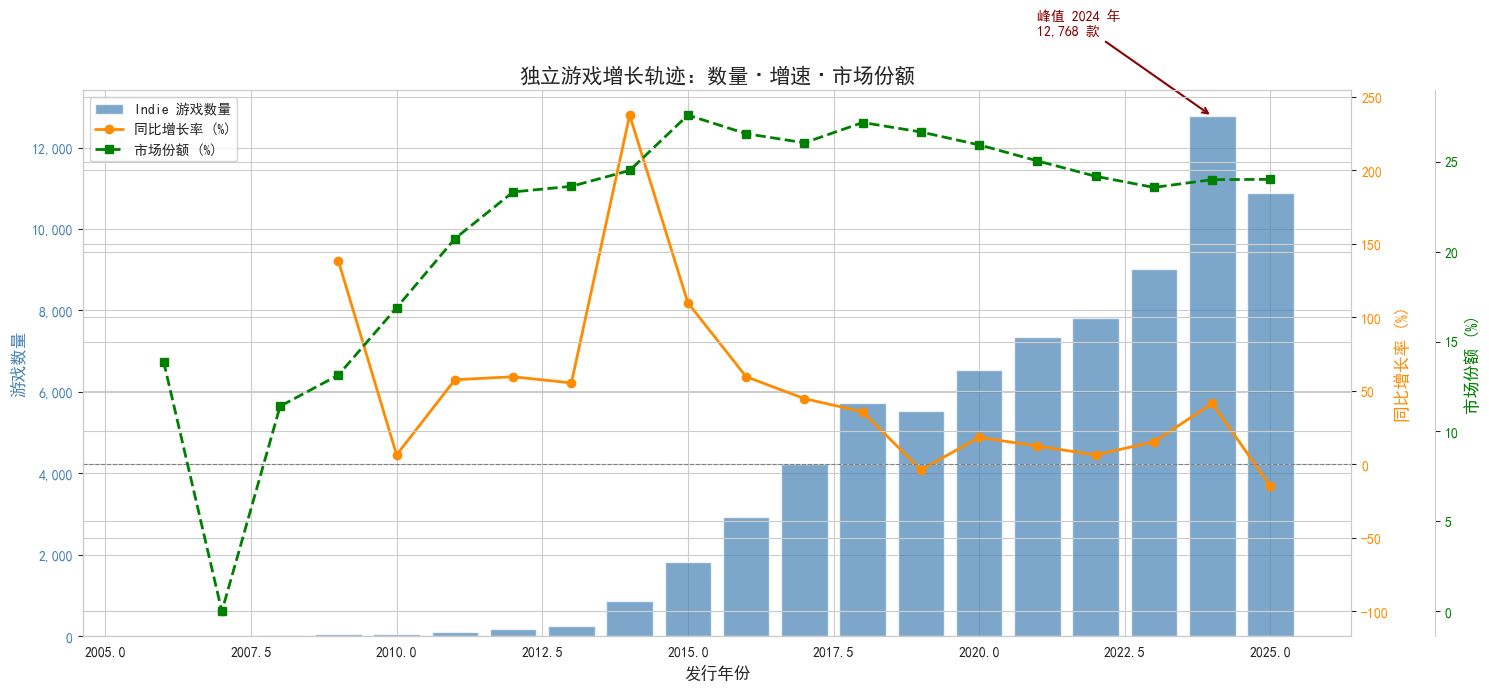

In [81]:
# 图表
fig, ax1 = plt.subplots(figsize=(15, 7))

# 柱状图：绝对数量
bars = ax1.bar(
    indie['release_year'], indie['game_count'],
    color='steelblue', alpha=0.7, label='Indie 游戏数量'
)
ax1.set_xlabel('发行年份', fontsize=12)
ax1.set_ylabel('游戏数量', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 标注峰值年份
peak_idx = indie['game_count'].idxmax()
ax1.annotate(
    f"峰值 {int(indie.loc[peak_idx, 'release_year'])} 年\n{int(indie.loc[peak_idx, 'game_count']):,} 款",
    xy=(indie.loc[peak_idx, 'release_year'], indie.loc[peak_idx, 'game_count']),
    xytext=(indie.loc[peak_idx, 'release_year'] - 3, indie.loc[peak_idx, 'game_count'] + 2000),
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
    fontsize=10, color='darkred', fontweight='bold'
)

# 折线1：增长率
ax2 = ax1.twinx()
ax2.plot(
    indie['release_year'], indie['yoy_growth'],
    color='darkorange', marker='o', linewidth=2, label='同比增长率 (%)'
)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_ylabel('同比增长率 (%)', fontsize=12, color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# 折线2：市场份额
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(
    indie['release_year'], indie['market_share'],
    color='green', marker='s', linewidth=2, linestyle='--', label='市场份额 (%)'
)
ax3.set_ylabel('市场份额 (%)', fontsize=12, color='green')
ax3.tick_params(axis='y', labelcolor='green')

# 图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left', fontsize=10)

plt.title('独立游戏增长轨迹：数量·增速·市场份额', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()